Kent Lin Chan

20202132

Se usó Python 3.14.2

Diseñar un filtro discreto IIR que permita el paso de frecuencias inferiores a 100 Hz con una frecuencia de muestreo de 800 Hz y rizado de la banda de paso $\varepsilon = 0.25$. El filtro debe diseñarse a partir de un filtro Chebyshev 1 analógico de orden 4, utilizando la transformación bilineal para convertir el filtro analógico a discreto. Para mapear las frecuencias discretas a continuas, utilizar:

$$\Omega = \frac{2}{T_s}\tan\left(\frac{\omega}{2}\right) \quad \text{donde} \quad \omega = \frac{2\pi f}{f_s} \;[\text{rad/muestra}]$$

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
%matplotlib inline

In [80]:
# Diseñando un Filtro Chebyshev
fs = 800
T = 1/fs

e = 0.25
fc = 100
w = (2*np.pi*fc)/fs
omg_c = (2/T)*np.tan(w/2)
n_order = 4

# Diseño del filtro analógico Chebyshev Tipo 1 con signal.cheby1
b_a, a_a = signal.cheby1(n_order, e, omg_c, btype='low', analog=True)

print(f"Coeficientes del numerador b_a ({len(b_a)} coefs):")
print(np.round(b_a, 6))
print(f"\nCoeficientes del denominador a_a ({len(a_a)} coefs):")
print(np.round(a_a, 6))

Coeficientes del numerador b_a (1 coefs):
[9.90670824e+10]

Coeficientes del denominador a_a (5 coefs):
[1.00000000e+00 9.61747429e+02 9.01705619e+05 4.03350621e+08
 1.01959893e+11]


<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:13: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:20: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:21: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:13: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:20: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences wil

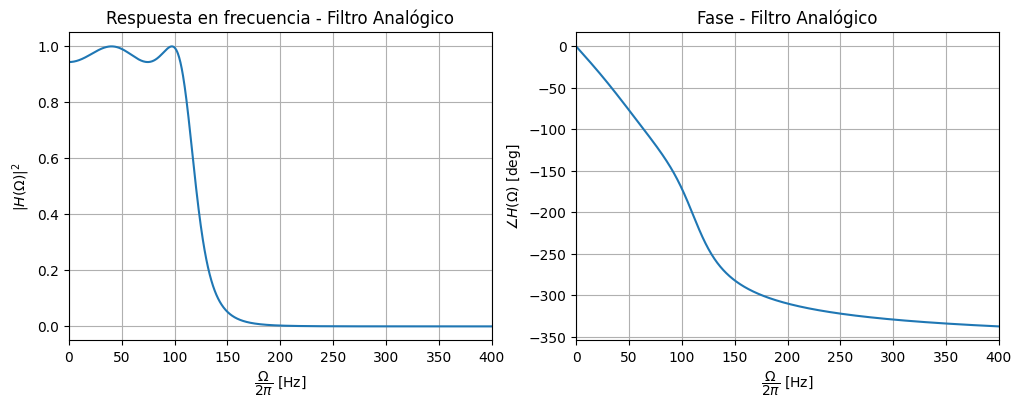

In [81]:
# Respuesta en frecuencia del filtro analógico en eje Ω
N = 1000
omg = np.arange(N)/N*(np.pi*fs)
_, H_a = signal.freqs(b_a, a_a, worN=omg)

fig = plt.figure(figsize=[12,4])

plt.subplot(1,2,1)
plt.plot(omg/(2*np.pi), np.abs(H_a)**2)
plt.xlim([0, fs/2])
plt.title("Respuesta en frecuencia - Filtro Analógico")
plt.xlabel('$\dfrac{\Omega}{2\pi}$ [Hz]')
plt.ylabel('$|H(\Omega)|^2$')
plt.grid('on')

plt.subplot(1,2,2)
plt.plot(omg/(2*np.pi), np.unwrap(np.angle(H_a))*180/np.pi)
plt.xlim([0, fs/2])
plt.title("Fase - Filtro Analógico")
plt.xlabel('$\dfrac{\Omega}{2\pi}$ [Hz]')
plt.ylabel('$\\angle H(\Omega)$ [deg]')
plt.grid('on')

<>:15: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:16: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:22: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:23: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:33: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:34: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:40: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences wil

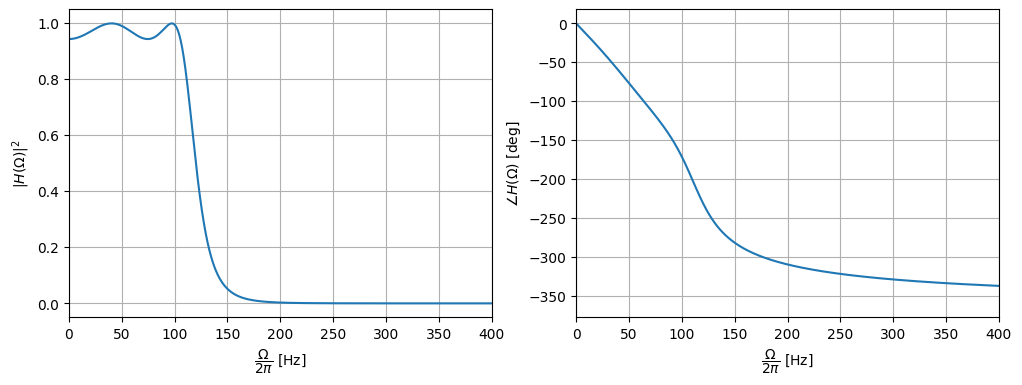

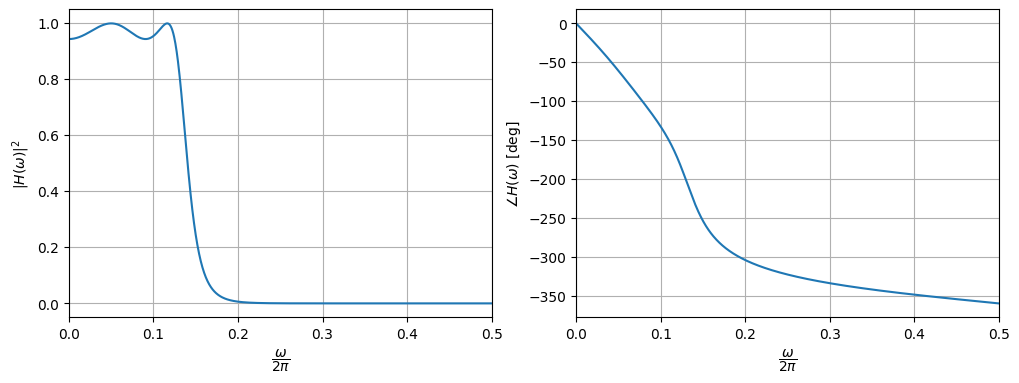

In [82]:
# Reparametrizando la respuesta analógica usando la transformación bilineal
alpha = 2/T

N = 1000
w_disc = np.arange(N)/N * np.pi
omg_bilin = alpha*np.tan(w_disc/2)
_, H_a_bilin = signal.freqs(b_a, a_a, worN=omg_bilin)

# Filtro analógico reparametrizado en eje f [Hz]
fig = plt.figure(figsize=[12,4])

plt.subplot(1,2,1)
plt.plot(omg_bilin/(2*np.pi), np.abs(H_a_bilin)**2)
plt.xlim([0, fs/2])
plt.xlabel('$\dfrac{\Omega}{2\pi}$ [Hz]')
plt.ylabel('$|H(\Omega)|^2$')
plt.grid('on')

plt.subplot(1,2,2)
plt.plot(omg_bilin/(2*np.pi), np.unwrap(np.angle(H_a_bilin))*180/np.pi)
plt.xlim([0, fs/2])
plt.xlabel('$\dfrac{\Omega}{2\pi}$ [Hz]')
plt.ylabel('$\\angle H(\Omega)$ [deg]')
plt.grid('on')


# Filtro analógico reparametrizado en eje ω/(2π) [adimensional]
fig = plt.figure(figsize=[12,4])

plt.subplot(1,2,1)
plt.plot(w_disc/(2*np.pi), np.abs(H_a_bilin)**2)
plt.xlim([0, 0.5])
plt.xlabel('$\dfrac{\omega}{2\pi}$')
plt.ylabel('$|H(\omega)|^2$')
plt.grid('on')

plt.subplot(1,2,2)
plt.plot(w_disc/(2*np.pi), np.unwrap(np.angle(H_a_bilin))*180/np.pi)
plt.xlim([0, 0.5])
plt.xlabel('$\dfrac{\omega}{2\pi}$')
plt.ylabel('$\\angle H(\omega)$ [deg]')
plt.grid('on')

In [83]:
# Discretización por transformación bilineal
b_d, a_d = signal.bilinear(b_a, a_a, fs=fs)

print(f"Coeficientes del numerador b_d ({len(b_d)} coefs):")
print(np.round(b_d, 6))
print(f"\nCoeficientes del denominador a_d ({len(a_d)} coefs):")
print(np.round(a_d, 6))

Coeficientes del numerador b_d (5 coefs):
[0.007312 0.029248 0.043872 0.029248 0.007312]

Coeficientes del denominador a_d (5 coefs):
[ 1.       -2.390982  2.606662 -1.418496  0.323225]


<>:9: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:9: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:9: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:9: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:9: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:16: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:17: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not

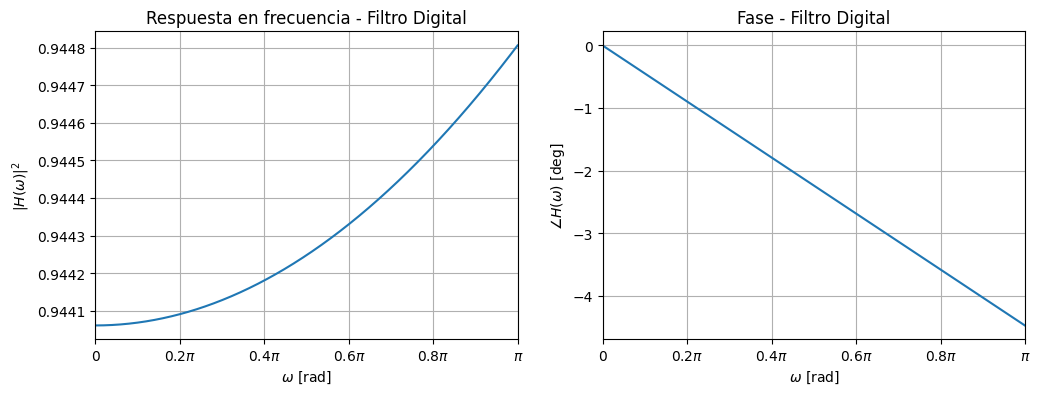

In [84]:
# Calculando el filtro H(z)
N = 1000
w = np.arange(N)/N * np.pi
_, H_d = signal.freqz(b_d, a_d, worN=w, fs=fs)

fig = plt.figure(figsize=[12,4])

xticks = [0, 0.2*np.pi, 0.4*np.pi, 0.6*np.pi, 0.8*np.pi, np.pi]
xticklab = ['0', '$0.2\pi$', '$0.4\pi$', '$0.6\pi$', '$0.8\pi$', '$\pi$']

plt.subplot(1,2,1)
plt.plot(w, np.abs(H_d)**2)
plt.xlim([0, np.pi])
plt.xticks(xticks, labels=xticklab)
plt.title("Respuesta en frecuencia - Filtro Digital")
plt.xlabel('$\omega$ [rad]')
plt.ylabel('$|H(\omega)|^2$')
plt.grid('on')

plt.subplot(1,2,2)
plt.plot(w, np.unwrap(np.angle(H_d))*180/np.pi)
plt.xlim([0, np.pi])
plt.xticks(xticks, labels=xticklab)
plt.title("Fase - Filtro Digital")
plt.xlabel('$\omega$ [rad]')
plt.ylabel('$\\angle H(\omega)$ [deg]')
plt.grid('on')

In [85]:
# Polos, ceros y ganancia del filtro discreto
z, p, k = signal.tf2zpk(b_d, a_d)

print(f"Número de polos: {len(p)}")
print(f"Número de ceros: {len(z)}")
print(f"Ganancia:        {k:.6f}")
print(f"\nTodos los polos dentro del círculo unitario: {np.all(np.abs(p) < 1)}")
print(f"Todos los ceros en el origen:                 {np.allclose(z, 0)}")

Número de polos: 4
Número de ceros: 4
Ganancia:        0.007312

Todos los polos dentro del círculo unitario: True
Todos los ceros en el origen:                 False


## Comentarios

**Frecuencia de corte analógica equivalente.** Por la condición de pre-warping de la transformación bilineal:

$$f_{c,\,\text{analógica}} = \frac{\Omega_c}{2\pi} = \frac{f_s}{\pi}\tan\!\left(\frac{\pi f_c}{f_s}\right) = \frac{800}{\pi}\tan\!\left(\frac{\pi}{8}\right) \approx 105.47\,\text{Hz}$$

Esta frecuencia analógica es **mayor que 100 Hz** porque la bilineal introduce *frequency warping*: el eje $\omega\in(-\pi,\pi)$ se mapea al eje $\Omega\in(-\infty,+\infty)$ mediante la tangente. Aplicando pre-warping al diseñar el prototipo analógico, garantizamos que **después** de la bilineal la frecuencia de corte discreta quede exactamente en 100 Hz.

**Diferencias entre analógico y discreto.**

- En la **banda de paso** ($\omega/2\pi \leq f_c/f_s = 0.125$), ambas respuestas presentan el rizado equiripple característico del Chebyshev 1 con $\varepsilon = 0.25$.
- En la **banda de rechazo**, la respuesta analógica decae monótonamente hacia cero cuando $\Omega \to \infty$. En cambio, la respuesta discreta se anula en $\omega = \pm\pi$ (Nyquist), reflejando la compresión de la bilineal: el eje infinito se mapea a $(-\pi,+\pi)$.
- En la **fase**, ambos son filtros de fase no lineal. Las curvas difieren progresivamente al alejarse del origen, consistente con la naturaleza de la bilineal.

**Estabilidad.** Todos los polos $z_k$ se ubican dentro del círculo unitario (verificado), por lo que el filtro discreto es estable.